# 🐧🐧Tarea 0 --- IELE756 🐧🐧
**Equipo Pinguino conformado por** : Hellen Quiñones, Gustavo Sánchez

**Region**: -no asignada-

**Date**: 12-03-25

**Link al repositorio de GitHub**: https://github.com/hellenelizabethqm-netizen/iele756-region-XXXX

### 🐧**PARTE 1: CENSO 2024**🐧 
 **1.1 Primero cargamos la base de datos y escogemos las columnas que ocuparemos**

In [21]:
pip install pyarrow #lo instalamos para que pueda leer el archivo.parquet

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: '#lo': Expected package name at the start of dependency specifier
    #lo
    ^


In [ ]:
#Primero cargamos la base de datos y escogemos las columnas que ocuparemos

import pandas as pd
persona = pd.read_parquet("personas_censo2024.parquet", columns=["region", "comuna", "sexo", "edad", "p27_nacionalidad", "p27_nacionalidad_rec", "escolaridad", "sit_fuerza_trabajo"])   


 **1.2 Inspeccionamos**

In [4]:
print("🐧 Filas y columnas 🐧 ")
print(persona.shape) #filas y columnas
print()
print("🐧 Tipos de datos 🐧 ")
print(persona.dtypes) #tipo de datos de la data
print()
print("🐧 Primeras filas 🐧 ")
print(persona.head(10)) #mostrar las primeras 10 filas
print()
print("🐧 Valores nulos?🐧 ")
print(persona.info()) #algún valor nulo? (null)


🐧 Filas y columnas 🐧 
(18480432, 8)

🐧 Tipos de datos 🐧 
region                    int32
comuna                    int32
sexo                      int32
edad                      int32
p27_nacionalidad          int32
p27_nacionalidad_rec      int32
escolaridad               int32
sit_fuerza_trabajo      float64
dtype: object

🐧 Primeras filas 🐧 
   region  comuna  sexo  edad  p27_nacionalidad  p27_nacionalidad_rec  \
0       5    5802     2    80                 1                     1   
1       5    5802     1    52                 1                     1   
2       5    5802     2    45                 1                     1   
3       5    5802     2     8                 1                     1   
4       4    4303     1    69                 1                     1   
5       4    4303     2    65                 1                     1   
6       4    4303     1    58                 1                     1   
7      11   11202     2   -66               -66                     

El dataset contiene **18,480,432 filas y 8 columnas**, donde cada fila representa a una persona registrada en el Censo 2024.

Las variables son:

* `region`: código numérico de la región de residencia.
* `comuna`: código numérico de la comuna.
* `sexo`: sexo de la persona.
* `edad`: edad en años.
* `p27_nacionalidad`: nacionalidad reportada.
* `p27_nacionalidad_rec`: variable recodificada que indica si la persona tiene nacionalidad chilena o no.
* `escolaridad`: nivel educacional alcanzado.
* `sit_fuerza_trabajo`: situación respecto a la fuerza laboral.

La mayoría de las variables están almacenadas como **enteros (`int32`)**, mientras que `sit_fuerza_trabajo` aparece como **`float64`**, lo que se explica debido al valor "NA" para los valores faltantes.

Al observar las primeras filas (`head()`), se confirma que las variables utilizan **códigos numéricos** para representar categorías, por lo que es necesario consultar el **diccionario de variables del censo** para interpretar correctamente su significado, de igual manera, en caso de usare, se explicarán los códigos usados.

Finalmente, se observa que  valores nulos con códigos especiales como **-66 o -99** que representan respuestas faltantes o no válidas al igual que **NA** para el No Aplica.


🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧
#### Descripción de variables – Dataset `personas_censo2024`

En este análisis utilizamos la base de microdatos **personas_censo2024**, que contiene información individual del Censo 2024 en Chile.
Cada fila del dataset representa una **persona censada** y cada columna corresponde a una **variable del cuestionario del censo**.

A continuación se describen las variables utilizadas en el análisis.

---

 `region`

Código numérico que identifica la **región donde reside la persona**.
Las regiones se representan mediante códigos oficiales del INE.

Ejemplos:

| Código | Región        |
| ------ | ------------- |
| 1      | Tarapacá      |
| 2      | Antofagasta   |
| 3      | Atacama       |
| 4      | Coquimbo      |
| 5      | Valparaíso    |
| 13     | Metropolitana |
| 16     | Ñuble         |

---

 `comuna`

Código numérico que identifica la **comuna de residencia** de la persona.
Cada comuna del país posee un código único.

Ejemplo:

| Código | Comuna   |
| ------ | -------- |
| 13101  | Santiago |
| 13119  | Maipú    |

---

 `sexo`

Variable que indica el **sexo de la persona**.

| Código | Categoría |
| ------ | --------- |
| 1      | Hombre    |
| 2      | Mujer     |

---

`edad`

Edad de la persona expresada en **años cumplidos** al momento del censo.

Algunos valores negativos pueden aparecer en los datos y representan **valores faltantes o no declarados**.

---

`p27_nacionalidad`

Variable que indica la **nacionalidad declarada por la persona** en la pregunta correspondiente del cuestionario censal.

Los códigos numéricos representan distintas nacionalidades según el diccionario de variables del Censo.

---

 `p27_nacionalidad_rec`

Variable recodificada de nacionalidad que agrupa las respuestas en categorías más generales.

| Código | Categoría  |
| ------ | ---------- |
| 1      | Chileno    |
| 2      | Extranjero |

Esta variable se utiliza en el análisis para calcular la proporción de población nacida en el extranjero.

---

 `escolaridad`

Variable que indica el **nivel educacional alcanzado por la persona**.

Los códigos numéricos representan distintos niveles de educación según el diccionario de variables del Censo.

Ejemplos de niveles posibles:

| Código | Nivel educativo         |
| ------ | ----------------------- |
| 1      | Sin educación formal    |
| 5      | Educación básica        |
| 10     | Educación media         |
| 15     | Educación técnica       |
| 17     | Educación universitaria |

---

`sit_fuerza_trabajo`

Variable que describe la **situación de la persona respecto al mercado laboral**.

| Código | Categoría  |
| ------ | ---------- |
| 1      | Ocupado    |
| 2      | Desocupado |
| 3      | Inactivo   |

---

### Valores faltantes

En algunas variables pueden aparecer códigos especiales que representan **datos faltantes o no respuesta**, por ejemplo:

| Código | Significado    |
| ------ | -------------- |
| -66    | No responde    |
| -99    | Valor faltante |

Estos valores deben considerarse al momento de realizar el análisis. 


 🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧🐧
 
 **1.3 Filtramos por region**

 Para este caso filtraremos los datos en una region de manera arbritaria hasta que se nos entregue la region o comuna respectiva. Por lo que se escogerá a Coquimbo.

 **Coquimbo: código territorial: 4**



In [7]:
#Se selecciona la columna region del data, en este caso el numero de Coquimbo es 4
my_region = persona[persona["region"] == 4]

#da la cantidad de personas dentro del nuevo data de la region de Coquimbo
print(f"Filas en Coquimbo: {len(my_region):,}") #el f permite agregar variables, el : que es un número y el , que el separador de miles es una coma

Filas en Coquimbo: 832,864


**1.4 Primer vistazo a la nacionalidad**

 Vamos a examinar la cantidad de extranjeros en la región escogida con la Variable `p27_nacionalidad_rec`

Esta variable indica si la persona tiene nacionalidad chilena según el diccionario de variables del Censo 2024.

| Código | Significado                                     |
| ------ | ----------------------------------------------- |
| 1      | Sí (tiene nacionalidad chilena)                 |
| 2      | No (no tiene nacionalidad chilena / extranjero) |
| -99    | No respuesta (dato faltante)                    |




In [13]:
#Queremos ver cuántos de cada uno hay en la región de Coquimbo
Cantidad = my_region["p27_nacionalidad_rec"].value_counts()

print(Cantidad)

p27_nacionalidad_rec
 1     787612
 2      40859
-99      4393
Name: count, dtype: int64


In [15]:
#ahora seleccionamos la columna p27_nacionalidad_rec de la data de nuestra región para contar cuántas hay de cada categoría
# el normalize vuelve la cantidad de cada uno (mostrada en la celda anterior) en una proporción
#dicha proporción se guarda en foreign

foreign = my_region["p27_nacionalidad_rec"].value_counts(normalize=True)
print(foreign)

p27_nacionalidad_rec
 1     0.945667
 2     0.049058
-99    0.005275
Name: proportion, dtype: float64


In [ ]:
#f permite colocar valores dentro de texto 
print(f"% foreign-born: {foreign.get(2, 0):.1%}") #la separación con un "." y el 1% es que te lo de en porcentaje con 1 decimal

% foreign-born: 4.9%


**Porcentaje de personas extranjeras**

Los resultados muestran que el 4,9% de la población de la región corresponde a personas extranjeras. 

Sin embargo, es importante notar que este porcentaje fue calculado usando `value_counts(normalize=True)`, por lo que incluye todos los registros de la base de datos, incluso aquellos con el valor **-99 (no respuesta)**. 



### **🐧PARTE 2: ENO - enfermedades de notificación obligatoria en Chile 🐧**
Entre ejemplos de este tipo de enfermedades tenemos: dengue, tuberculosis, VIH, etc.

Cada fila del dataset es un caso reportado.

Este cubre desde el año 2007 al 2024

 **2.1 Al igual que en el 1.1, primero cargamos la base de datos**

 

In [ ]:
eno = pd.read_csv("20241218_base_eno_final.csv",
sep=";", encoding="utf-8-sig")

print(f"Total rows: {len(eno):,}")
print(eno.columns.tolist())

C:\Users\helle\AppData\Local\Temp\ipykernel_21872\401542580.py:1: DtypeWarning: Columns (0: Autóctono, 1: presenta_sintomas, 2: sintomas, 3: consumo_agua_no_potable, 4: antecedente_teniasis, 5: imagenologia, 6: manifestaciones, 7: existe_coinfeccion, 8: via_transmision, 9: n_parejas_sexuales, 10: uso_preservativo, 11: paciente_inmunosuprimido, 12: vih, 13: pareja, 14: exantema_mpox, 15: factores_exposicion, 16: neumonia, 17: contacto_aves, 18: genotipo_1, 19: recuento_linfocitos, 20: clasificacion_final_vih, 21: etapa_vih_sida, 22: hospitalizacion, 23: nombre_primer_sintoma, 24: SeroGrupo) have mixed types. Specify dtype option on import or set low_memory=False.
  eno = pd.read_csv("20241218_base_eno_final.csv",


Total rows: 333,300
['etapa_clinica', 'region', 'seremi', 'nacionalidad', 'cie_10_diagnostico', 'diagnostico', 'Autóctono', 'anho_notificacion', 'ENO', 'pueblo_indigena', 'nombre_instruccion', 'presenta_sintomas', 'sintomas', 'consumo_agua_no_potable', 'antecedente_teniasis', 'imagenologia', 'manifestaciones', 'existe_coinfeccion', 'via_transmision', 'n_parejas_sexuales', 'uso_preservativo', 'pais_contagio', 'paciente_inmunosuprimido', 'vih', 'pareja', 'exantema_mpox', 'factores_exposicion', 'neumonia', 'contacto_aves', 'genotipo_1', 'recuento_linfocitos', 'clasificacion_final_vih', 'etapa_vih_sida', 'hospitalizacion', 'nombre_primer_sintoma', 'SeroGrupo', 'sexo', 'grupo_edad', 'codigo_comuna_residencia']


En total tenemos 333390 pacientes (filas) y 39 columnas de características.

Además. observamos las primeras 10 filas para darnos una idea de lo que ocurre,además de observar todos los nombres de la columna de "region" para ver los nombres disponibles.

In [20]:
print(eno.head(10))
eno["region"].unique()

  etapa_clinica                            region      seremi nacionalidad  \
0    CONFIRMADA                Región de Tarapacá    TARAPACÁ   Extranjero   
1    CONFIRMADA              Región de Valparaíso  VALPARAÍSO  Desconocido   
2    CONFIRMADA              Región de Valparaíso  VALPARAÍSO        Chile   
3    CONFIRMADA              Región de Valparaíso  VALPARAÍSO   Extranjero   
4    CONFIRMADA              Región de Valparaíso  VALPARAÍSO        Chile   
5    CONFIRMADA  Región Metropolitana de Santiago          RM        Chile   
6    CONFIRMADA  Región Metropolitana de Santiago          RM        Chile   
7    CONFIRMADA  Región Metropolitana de Santiago          RM        Chile   
8    CONFIRMADA  Región Metropolitana de Santiago          RM        Chile   
9    CONFIRMADA              Región de Valparaíso  VALPARAÍSO        Chile   

  cie_10_diagnostico                 diagnostico Autóctono  anho_notificacion  \
0              A97.0  DENGUE SIN DATOS DE ALARMA        No  

<ArrowStringArray>
[                                 'Región de Tarapacá',
                                'Región de Valparaíso',
                    'Región Metropolitana de Santiago',
                                 'Región de Los Lagos',
                        'Región de Arica y Parinacota',
                                   'Región del Biobío',
                                  'Región de Los Ríos',
                               'Región de Antofagasta',
                              'Región de la Araucanía',
     'Región del Libertador General Bernardo OHiggins',
 'Región de Aysén del General Carlos Ibáñez del Campo',
                                    'Región del Ñuble',
                                    'Región del Maule',
                                   'Región de Atacama',
                                  'Región de Coquimbo',
         'Región de Magallanes y la Antártica Chilena',
                                         'Desconocido']
Length: 17, dtype: str

 **2.2 Ahora filtraremos con nuestra region la data**
 Mientras se espera que se nos designe una región, la Region de Coquimbo será mientras tanto con la que trabajaremos.

 Podremos ver que existen 21373 datos de ENO en la Región de Coquimbo en total a través de los años.

In [23]:
eno_region = eno[eno["region"] == "Región de Coquimbo"]
print(f"Filas en mi region: {len(eno_region):,}")

Filas en mi region: 21,373


**2.3 Enfermedades notificables por año**
El número anterior fue el total entre los años 2007-2024, por lo que separaremos dichos casos por año.



In [25]:
#anho_notificacion es la columna que contiene el año de notificación del caso
#value counts cuenta los valores según los años que aparezcan diferentes en anho
#sort index los ordena de menor a mayor

cases_by_year = eno_region["anho_notificacion"].value_counts().sort_index()

print(cases_by_year)

anho_notificacion
2007     526
2008     568
2009     843
2010     805
2011    1458
2012    1033
2013     612
2014     780
2015     898
2016     850
2017    1151
2018    1383
2019    1253
2020     722
2021     973
2022    1392
2023    4615
2024    1511
Name: count, dtype: int64


Ahora, con los casos por año, podemos realizar la gráfica de barras cantidad de casos por año

Text(0.5, 1.0, 'Casos de enfermedades de notificación obligatoria en la Región de Coquimbo entre los años 2007-2024')

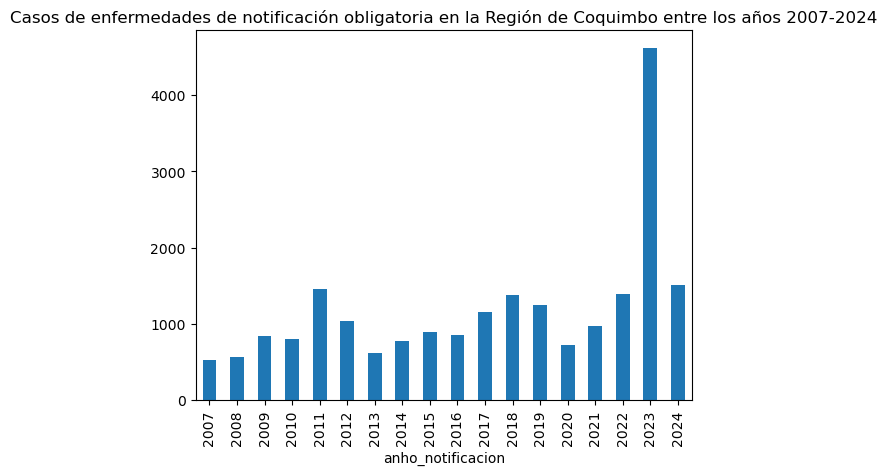

In [30]:
import  matplotlib.pyplot as plt

cases_by_year.plot(kind="bar")
plt.title("Casos de enfermedades de notificación obligatoria en la Región de Coquimbo entre los años 2007-2024")

En este podemos observar que el año 2023 es el año con más pacientes reportados (ENO).

**2.4 Enfermedades más notificadas en la región**

En este caso se muestran las 5 enfermedades más notificadas en la región entre los años 2007-2024.

In [34]:
#Por cada carácteristica value se cuenta y se muestran las 5 primeras
print(eno_region["ENO"].value_counts().head(5))

top5ENO = eno_region["ENO"].value_counts().head(5)

ENO
Chagas                  9731
Sifilis                 4487
VIH                     2215
Infección gonocócica    1617
Parotiditis              783
Name: count, dtype: int64


Ahora en base a ello creamos el gráfico de barras horizontal, el cual muestra que "Chagas" es la ENO más común en Coquimbo.

<Axes: title={'center': 'TOP 5 ENO en Coquimbo'}, ylabel='ENO'>

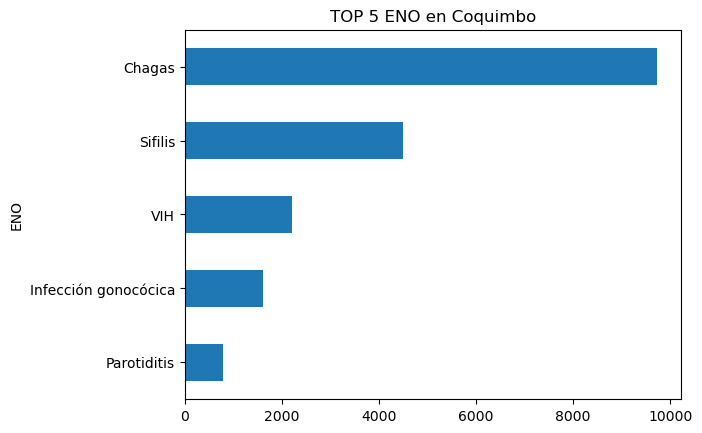

In [39]:
plt.title("TOP 5 ENO en Coquimbo")
top5ENO.sort_values().plot(kind="barh")

**2.5 Distribución de nacionalidades de las personas notificadas en el dataset ENO en la región designada**

Para esto se deben contar cuántos casos hay por nacionalidad usando el .value counts en la columna "nacionalidad". En este se puede ver una categoría de "desconocido" si se desconoce la nacionalidad, la cual mantendremos.

In [ ]:
#cantidad
eno_region["nacionalidad"].value_counts()

nacionalidad
Chile          14218
Desconocido     5850
Extranjero      1305
Name: count, dtype: int64

In [42]:
#Porcentaje
eno_region["nacionalidad"].value_counts(normalize=True)

nacionalidad
Chile          0.665232
Desconocido    0.273710
Extranjero     0.061058
Name: proportion, dtype: float64

Los datos muestran que la mayoría de las notificaciones en la región corresponden a personas de nacionalidad chilena, representando aproximadamente el 66.5% de los casos registrados en el dataset ENO. También se observa una proporción considerable de registros con nacionalidad desconocida (27.4%), es decir, en dichos casos la nacionalidad no fue reportada.

Finalmente, las personas extranjeras representan cerca del 6.1% de las notificaciones totales en la región.


### **🐧PARTE 3: GRD - Hospital Discharges 🐧**

Los archivos GRD contienen información sobre egresos hospitalarios en Chile.

Los datos vienen comprimidos en archivos ZIP y cada archivo tiene 129 columnas.

Para optimizar la carga de datos se seleccionan únicamente las columnas necesarias utilizando `usecols`.

### 3.1 Cargar datos GRD ###

In [2]:
import zipfile
import pandas as pd

cols = ["COMUNA", "NACIONALIDAD", "SEXO", "DIAGNOSTICO1",
        "FECHA_INGRESO", "FECHAALTA",
        "IR_29301_SEVERIDAD", "IR_29301_COD_GRD"]

with zipfile.ZipFile("grd_temp/GRD_PUBLICO_2024.zip") as z:
    with z.open("GRD_PUBLICO_2024.txt") as f:
        grd = pd.read_csv(f, sep="|",usecols=cols, 
                          low_memory=False,encoding="latin-1")

print(f"Total discharges: {len(grd):,}")
grd.head()

Total discharges: 1,085,813


,SEXO,COMUNA,NACIONALIDAD,FECHA_INGRESO,FECHAALTA,DIAGNOSTICO1,IR_29301_COD_GRD,IR_29301_SEVERIDAD
0,MUJER,VILLA ALEMANA,CHILE,2024-03-23,2024-03-23,H26.9,022360,0
1,MUJER,VIÑA DEL MAR,CHILE,2024-09-26,2024-10-02,M31.1,041023,3
2,HOMBRE,LA SERENA,CHILE,2024-01-22,2024-01-26,K12.2,034141,1
3,HOMBRE,ÑUÑOA,CHILE,2024-04-08,2024-04-14,C61,061203,3
4,MUJER,SAN PEDRO DE LA PAZ,PERÚ,2024-09-24,2024-09-26,K35.8,061131,1


### 3.2 Filter your region ###

- Sabemos que los archivos de GRD no cuentan con la columna de  "REGION", por lo que colocamos en una lista las comunas correspondientes a la región seleccionada (**Coquimbo**)

In [3]:
my_comuna = ["LA SERENA", "COQUIMBO","ANDACOLLO", "LA HIGUERA", "PAIGUANO", "VICUÑA","PAIHUANO","OVALLE","MONTE PATRIA","COMBARBALA","ILLAPEL",
             "PUNITAQUI","LOS VILOS","SALAMANCA","CANELA","RIO HURTADO"]
grd_region = grd[grd["COMUNA"].isin(my_comuna)]
print(f"Discharges in Coquimbo: {len(grd_region):,}")


Discharges in Coquimbo: 51,189


- El primer paso corresponde a enlistar las comunas que se encuentran dentro de la región seleccionada (Coquimbo)🐧para seleccionar únicamente los egresos hospitalarios correspondientes a Coquimbo, indicandonos una cantidad de 51,189 egresos, este conjunto de datosse utilizará para identificar los diagnósticos más frecuentes en los siguientes pasos.

### 3.3 Join with CIE-10 

In [4]:
cie10 = pd.read_excel("grd_temp/CIE-10.xlsx",
                      sheet_name="CIE 10")

grd_region = grd_region.merge(
    cie10[["Código", "Descripción", "Capítulo"]],
    left_on="DIAGNOSTICO1", right_on="Código",
    how="left")     

Primero cargamos el archivo **CIE-10**, asociados a distintas enfermedades. A continuación se muestran algunos ejemplos de estos códigos y su significado:

| Código | Significado                                    |
| ------ | ---------------------------------------------- |
| B15    | Hepatitis aguta tipo A                         |
| J18.9  | Neumania por microorganismo no identificado    |
| E11    | Diabetes mellitus no insulnodependiente        |

- El objetivo de leer este archivo es combinarlo con el dataset anterior, de manera que sea posible identificar para cada registro el código de la enfermedad, su descripción y el capítulo correspondiente, el cual corresponde a una categoría amplia que agrupa enfermedades según el sistema del cuerpo o el tipo de condición médica (por ejemplo, enfermedades respiratorias, infecciosas o metabólicas)

### 3.4 Top 5 Diagnoses

A continuación se identifican los cinco diagnósticos más frecuentes en la Región de Coquimbo.   
Contando la cantidad de veces que aparece cada diagnóstico en la columna **Descripción**.

In [7]:
grd_region["Descripción"].value_counts().head(5)

Descripción
Catarata, no especificada                                   4491
Parto único espontáneo, presentación cefálica de vértice     966
Cálculo de la vesícula biliar sin colecistitis               918
Pterigión                                                    721
Parto por cesárea electiva                                   668
Name: count, dtype: int64

Los resultados muestran los cinco diagnósticos más frecuentes registrados en los egresos hospitalarios de la Región de Coquimbo. Se observa que **catarata, no especificada** es el diagnóstico con mayor número de casos, con una diferencia considerable respecto a los demás. 

También aparecen diagnósticos relacionados con el **parto**, como el parto único espontáneo y la cesárea electiva, lo que refleja la importancia de los servicios obstétricos dentro de los registros hospitalarios. Otros diagnósticos frecuentes incluyen el **cálculo de la vesícula biliar** y el **pterigión**, condiciones médicas relativamente comunes en la atención hospitalaria.

- En base a ello presentamos el gráfico en barra de los diagnosticos mas comunes en la región de Coquimbo en 2024

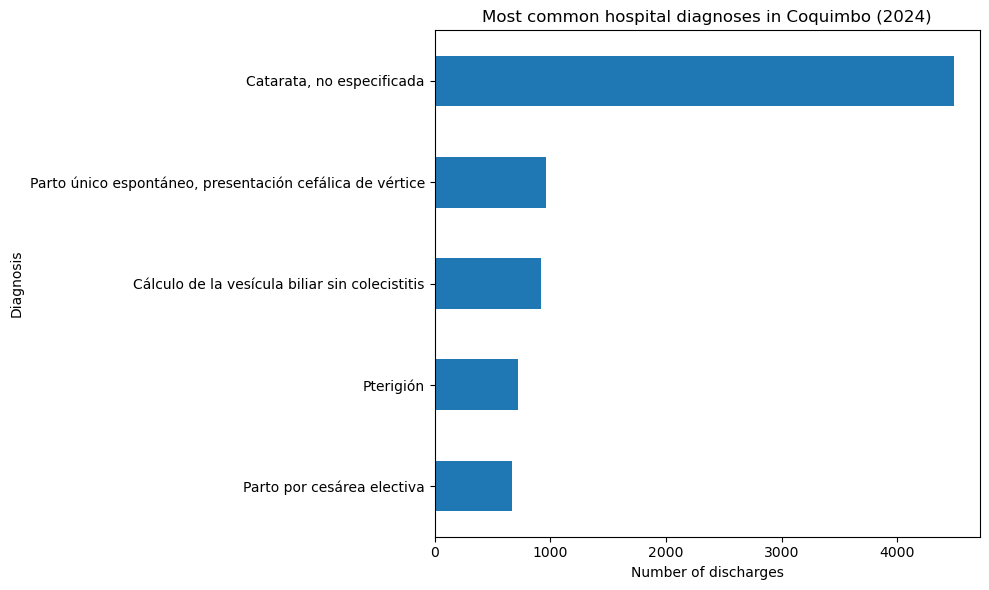

In [10]:
import matplotlib.pyplot as plt

top10 = grd_region["Descripción"].value_counts().head(5)

plt.figure(figsize=(10,6))

top10.sort_values().plot(kind="barh")

plt.xlabel("Number of discharges")
plt.ylabel("Diagnosis")
plt.title("Most common hospital diagnoses in Coquimbo (2024)")

plt.tight_layout()
plt.show()